<h1> <center> BIG DATA AND DATA MINING </center> </h1>

<h2>Part (a) – Road Traffic Accident Data Analysis & Policy Recommendations</h2>

In [1]:
# import dictionaries
import pandas as pd 
import numpy as np
import sqlite3 
import os 
import matplotlib.pyplot as plt

# create path 
path = r"C:\Users\Harashaa Harshini\OneDrive\Desktop\MSC Assignments\Big data"
file_path = path + "\accident_data_v1.0.0_2023 (1).db"

### Reading and exploring a `.db` file with SQLite and Pandas

The following code checks whether the database file exists, connects to the `.db` database, retrieves all available table names, and closes the connection securely.



In [2]:
path = r"C:\Users\Harashaa Harshini\OneDrive\Desktop\MSC Assignments\Big data"
file_path = os.path.join(path, "accident_data_v1.0.0_2023 (1).db")

# Check if the file exists at the given path
print("Path exists:", os.path.exists(file_path))

# Connect to the SQLite database (.db file)
conn = sqlite3.connect(file_path)
cursor = conn.cursor()

# Query to list all table names in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())  # Display tables found

# Close the database connection
conn.close()

Path exists: True
[('accident',), ('casualty',), ('vehicle',), ('lsoa',)]


In [3]:
conn = sqlite3.connect(file_path)

df_2019 = pd.read_sql_query("Select * from accident where accident_year = 2019 ;", conn)
lsoa = pd.read_sql_query("select * from lsoa;", conn)
df_veh = pd.read_sql_query("SELECT * FROM vehicle where accident_year = 2019;", conn)
df_cas = pd.read_sql_query("SELECT * FROM casualty where accident_year = 2019;", conn)
df_acc = pd.read_sql_query("Select * from accident where accident_year < 2020;", conn)
conn.close()


In [4]:
df_2019.head()


,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
0,2019010128300,2019,010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,...,5,1,1,1,0,0,1,3,2,E01004762
1,2019010152270,2019,010152270,530219.0,172463.0,-0.127949,51.436208,1,3,2,...,9,4,1,1,0,0,1,3,2,E01003117
2,2019010155191,2019,010155191,530222.0,182543.0,-0.124193,51.526795,1,3,2,...,0,4,1,1,0,0,1,1,2,E01000943
3,2019010155192,2019,010155192,525531.0,184605.0,-0.191044,51.546387,1,2,1,...,0,4,1,1,0,0,1,1,2,E01000973
4,2019010155194,2019,010155194,524920.0,184004.0,-0.200064,51.541121,1,3,2,...,0,4,1,1,0,0,1,1,2,E01000546


In [5]:
df_veh.head()


,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
0,465335,2019010128300,2019,010128300,1,9,0,99,9,9,...,6,1,58,9,-1,-1,-1,-1,2,1
1,465336,2019010128300,2019,010128300,2,9,0,99,9,9,...,6,3,-1,-1,-1,-1,-1,-1,2,1
2,465337,2019010152270,2019,010152270,1,9,0,18,9,9,...,6,2,24,5,-1,-1,-1,-1,3,1
3,465338,2019010152270,2019,010152270,2,9,0,18,9,9,...,6,3,-1,-1,-1,-1,-1,-1,6,1
4,465339,2019010155191,2019,010155191,1,9,0,3,5,1,...,6,1,45,7,-1,-1,-1,-1,4,1


In [6]:

df_cas.head()

,casualty_index,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
0,331590,2019010128300,2019,010128300,1,1,1,1,58,9,3,0,0,0,0,0,9,1,2
1,331591,2019010128300,2019,010128300,1,2,2,2,-1,-1,3,0,0,1,0,0,9,1,5
2,331592,2019010128300,2019,010128300,1,3,2,2,-1,-1,3,0,0,2,0,0,9,1,5
3,331593,2019010152270,2019,010152270,1,1,1,2,24,5,3,0,0,0,0,0,9,1,3
4,331594,2019010155191,2019,010155191,2,1,2,2,21,5,3,0,0,0,0,0,1,1,1


In [7]:
lsoa.head()

,objectid,lsoa01cd,lsoa01nm,lsoa01nmw,shape__area,shape__length,globalid
0,1,E01000001,City of London 001A,City of London 001A,1.298652e+05,2635.772001,68cc6127-1008-4fbe-a16c-78fb089a7c43
1,2,E01000002,City of London 001B,City of London 001B,2.284189e+05,2707.986202,937edbc3-c1bf-4d35-b274-b0a1480a7c09
2,3,E01000003,City of London 001C,City of London 001C,5.905477e+04,1224.774479,2686dcaf-10b9-4736-92af-4788d4feaa69
3,4,E01000004,City of London 001D,City of London 001D,2.544551e+06,10718.466240,3c493140-0b3f-4b9a-b358-22011dc5fb89
4,5,E01000005,City of London 001E,City of London 001E,1.895782e+05,2275.809358,b569093d-788d-41be-816c-d6d7658b2311


In [8]:
df_acc['accident_year'].unique()

array([2017, 2018, 2019])

### 🚔 Database Query & Summary Extraction

This snippet connects to a SQLite database and performs quick exploratory queries. It prints the total number of accident records for 2019, then extracts distinct police forces and geographic identifiers (LSOAs) directly via SQL. Finally, it closes the connection to free resources.


In [9]:
conn = sqlite3.connect(file_path)

print("total no. of accidents = ", len(df_2019))

# Get unique police forces
df_police = pd.read_sql_query("SELECT DISTINCT police_force FROM accident where accident_year = 2019;", conn)
print("Number of police forces:", len(df_police))

df_geo = pd.read_sql_query("SELECT DISTINCT lsoa_of_accident_location FROM accident;", conn)
print("Unique geographic codes:", len(df_geo))

conn.close()

total no. of accidents =  117536
Number of police forces: 51
Unique geographic codes: 33748


### ⏱️ Temporal Accident Pattern Analysis

This snippet preprocesses date and time fields to derive accident patterns. It extracts hours and weekday indicators, then identifies peak and low accident times, compares **weekday vs. weekend averages**, and evaluates rush-hour accident intensity. These aggregated insights enable temporal trend interpretation for safety analysis.


In [10]:

# If datetime is split, create unified date_time column (adjust field names if needed)
# Convert time and date fields
# Convert time to hour
df_2019['time'] = pd.to_datetime(df_2019['time'], format='%H:%M', errors='coerce')
df_2019['hour'] = df_2019['time'].dt.hour

# Convert date and extract day of week (1=Mon ... 7=Sun)
df_2019['date'] = pd.to_datetime(df_2019['date'], errors='coerce')
df_2019['day_of_week'] = df_2019['date'].dt.dayofweek + 1


# ---- Peak and lowest accident hour ----
peak_hour = df_2019['hour'].value_counts().idxmax()
peak_hour_count = df_2019['hour'].value_counts().max()

lowest_hour = df_2019['hour'].value_counts().idxmin()
lowest_hour_count = df_2019['hour'].value_counts().min()

# ---- Highest accident day ----
highest_day = df_2019['day_of_week'].value_counts().idxmax()
highest_day_count = df_2019['day_of_week'].value_counts().max()

# ---- Weekday vs weekend averages ----
weekday_avg = df_2019[df_2019['day_of_week'].isin([1,2,3,4,5])].shape[0] / 5
weekend_avg = df_2019[df_2019['day_of_week'].isin([6,7])].shape[0] / 2
difference = weekday_avg - weekend_avg

# ---- Rush hour analysis ----
rush_hours = df_2019[df_2019['hour'].isin([8,9,16,17,18])]
rush_hour_avg = rush_hours.shape[0] / 5

non_rush_hours = df_2019[~df_2019['hour'].isin([8,9,16,17,18])]
non_rush_hour_avg = non_rush_hours.shape[0] / 19

# ---- Print summary ----
print("Peak hour:", peak_hour, "| Accidents:", peak_hour_count)
print("Lowest hour:", lowest_hour, "| Accidents:", lowest_hour_count)
print("Highest accident day (1=Mon..7=Sun):", highest_day, "| Accidents:", highest_day_count)
print("Weekday avg accidents:", weekday_avg)
print("Weekend avg accidents:", weekend_avg)
print("Difference (weekday - weekend):", difference)
print("Rush-hour avg accidents (08–09 & 16–18):", rush_hour_avg)
print("Non-rush-hour avg accidents:", non_rush_hour_avg)

Peak hour: 17 | Accidents: 10198
Lowest hour: 4 | Accidents: 791
Highest accident day (1=Mon..7=Sun): 5 | Accidents: 19056
Weekday avg accidents: 17809.0
Weekend avg accidents: 14245.5
Difference (weekday - weekend): 3563.5
Rush-hour avg accidents (08–09 & 16–18): 8326.2
Non-rush-hour avg accidents: 3995.0


C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\2633278197.py:8: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_2019['date'] = pd.to_datetime(df_2019['date'], errors='coerce')


### 📊 **Visual Analytics of Temporal Accident Patterns**

This snippet constructs **three key visualisations** to analyse accident distribution across time dimensions:

- A **line plot** showing *hourly accident frequency* 📈, helpful to identify peak hours.
- A **bar chart** of *accidents by weekday* 📅, revealing weekly pattern variations.
- A **heatmap** 🌡️ mapping accidents by **hour vs. day**, enabling intuitive detection of high-risk intersections in time.

These visual tools support **evidence-based traffic safety insights** by clearly highlighting temporal risk zones.


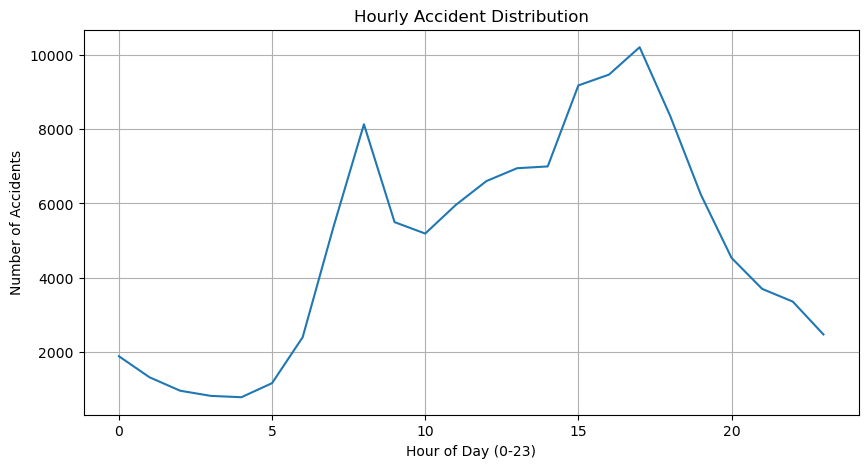

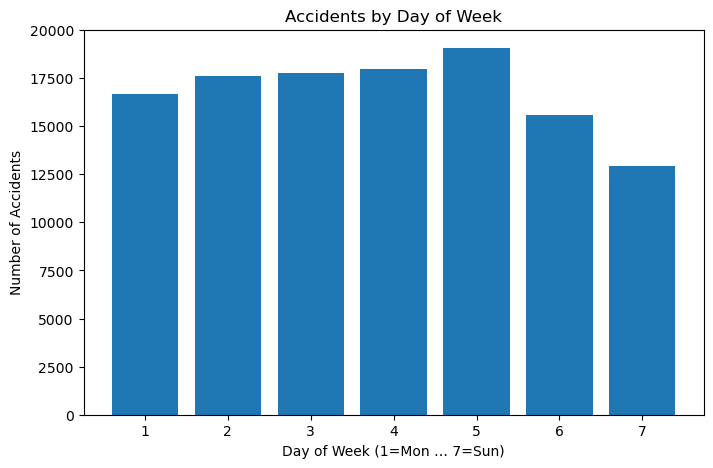

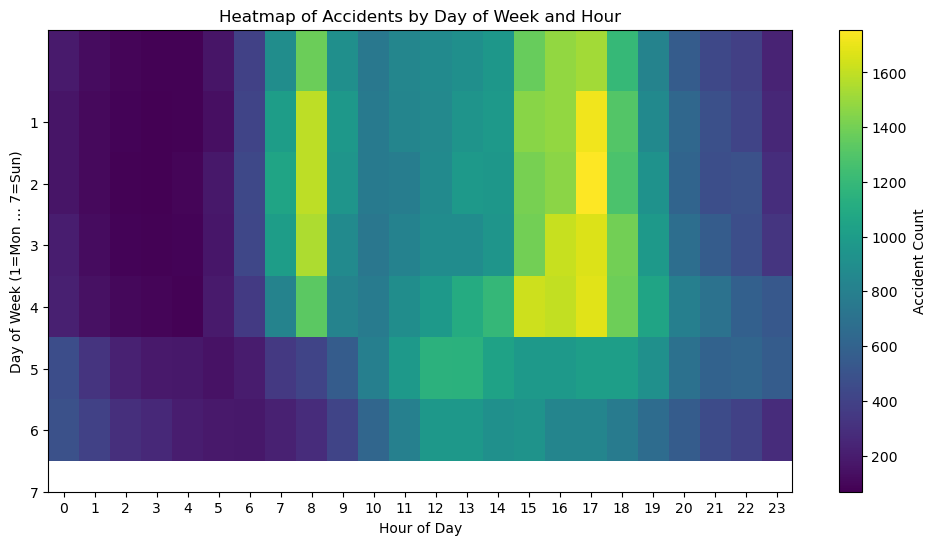

In [11]:

save = os.path.join(path, "Hourly Accident Distribution.png")
# Hourly accident distribution
hour_counts = df_2019['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(hour_counts.index, hour_counts.values)
plt.title("Hourly Accident Distribution")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.savefig(save)
plt.show()

save = os.path.join(path, "Accidents by Day of Week.png")
# Day of week accident distribution
day_counts = df_2019['day_of_week'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(day_counts.index, day_counts.values)
plt.title("Accidents by Day of Week")
plt.xlabel("Day of Week (1=Mon … 7=Sun)")
plt.ylabel("Number of Accidents")
plt.xticks([1,2,3,4,5,6,7])
plt.savefig(save)
plt.show()

save = os.path.join(path, "Heatmap of Accidents.png")
# Create pivot table day x hour
heat_data = df_2019.pivot_table(index='day_of_week', columns='hour', aggfunc='size', fill_value=0)

plt.figure(figsize=(12,6))
plt.imshow(heat_data, aspect='auto')
plt.colorbar(label='Accident Count')
plt.title("Heatmap of Accidents by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (1=Mon … 7=Sun)")
plt.xticks(np.arange(0, 24, 1))
plt.yticks(np.arange(1, 8, 1))
plt.savefig(save)
plt.show()

### 🏍️ **Motorcycle Accident Segmentation & Temporal Metrics**

This snippet merges accident and vehicle datasets and performs **engine-capacity–based segmentation** to analyse motorcycle accidents. It filters valid capacity values and categorises them into three groups (**≤125cc**, **125–500cc**, **>500cc**). Temporal variables (hour and weekday) are derived to compute:

- **Peak & lowest accident hours** per engine class ⏰
- **Day-of-week accident intensity** per category 📅
- **Weekday vs. weekend averages** to assess commuting vs leisure patterns
- **Rush-hour vs non-rush-hour comparisons** for behavioural insights
- **Difference between most and least frequent engine classes**, quantifying severity spread

These metrics provide a **granular temporal-risk profile** across motorcycle engine categories.


In [12]:

# Merge accidents and vehicles using accident_index
df_mc = df_2019.merge(df_veh, on="accident_index", how="inner")

# Filter valid engine capacity values (remove unknown = -1)
df_mc = df_mc[df_mc['engine_capacity_cc'] > 0]

# Create engine categories
df_mc['engine_group'] = pd.cut(
    df_mc['engine_capacity_cc'],
    bins=[0, 125, 500, 10000],
    labels=['≤125cc', '125–500cc', '>500cc']
)

# Convert date/time fields
df_mc['time'] = pd.to_datetime(df_mc['time'], format='%H:%M', errors='coerce')
df_mc['hour'] = df_mc['time'].dt.hour

df_mc['date'] = pd.to_datetime(df_mc['date'], errors='coerce')
df_mc['day_of_week'] = df_mc['date'].dt.dayofweek + 1  # 1=Mon … 7=Sun

# -------- METRICS --------

# Total motorcycle accidents
total_mc = df_mc.shape[0]

# Total accidents per engine group
engine_counts = df_mc['engine_group'].value_counts()

# Accident counts per hour per engine group
by_hour = df_mc.groupby(['engine_group', 'hour']).size()

# Accident counts per day per engine group
by_day = df_mc.groupby(['engine_group', 'day_of_week']).size()

# Peak hour per engine class
peak_hour = by_hour.groupby('engine_group').idxmax()
peak_hour_values = by_hour.groupby('engine_group').max()

# Lowest hour per engine class
lowest_hour = by_hour.groupby('engine_group').idxmin()
lowest_hour_values = by_hour.groupby('engine_group').min()

# Peak day of week
peak_day = by_day.groupby('engine_group').idxmax()
peak_day_values = by_day.groupby('engine_group').max()

# Weekday vs weekend
weekday_avg = df_mc[df_mc['day_of_week'].isin([1,2,3,4,5])].groupby('engine_group').size() / 5
weekend_avg = df_mc[df_mc['day_of_week'].isin([6,7])].groupby('engine_group').size() / 2

# Difference largest vs smallest class
group_diff = engine_counts.max() - engine_counts.min()

# Rush hour vs non-rush hour
rush = df_mc[df_mc['hour'].isin([8,9,16,17,18])].groupby('engine_group').size() / 5
nonrush = df_mc[~df_mc['hour'].isin([8,9,16,17,18])].groupby('engine_group').size() / 19

# ----- PRINT RESULTS -----
print("\n--- MOTORCYCLE TEMPORAL METRICS ---")
print("Total motorcycle accidents:", total_mc)
print("\nTotal by engine group:\n", engine_counts)
print("\nPeak hour per engine group:\n", peak_hour)
print("\nLowest hour per engine group:\n", lowest_hour)
print("\nPeak day of week per engine type:\n", peak_day)
print("\nWeekday vs Weekend averages:\n", weekday_avg, "\n", weekend_avg)
print("\nDifference largest vs smallest engine group:", group_diff)
print("\nRush hour vs Non-rush hour:\n", rush, "\n", nonrush)


C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1771906197.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_hour = df_mc.groupby(['engine_group', 'hour']).size()
C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1771906197.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_day = df_mc.groupby(['engine_group', 'day_of_week']).size()
C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1771906197.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior


--- MOTORCYCLE TEMPORAL METRICS ---
Total motorcycle accidents: 161423

Total by engine group:
 engine_group
>500cc       149918
≤125cc         8495
125–500cc       822
Name: count, dtype: int64

Peak hour per engine group:
 engine_group
≤125cc          (≤125cc, 17)
125–500cc    (125–500cc, 17)
>500cc          (>500cc, 17)
dtype: object

Lowest hour per engine group:
 engine_group
≤125cc          (≤125cc, 3)
125–500cc    (125–500cc, 3)
>500cc          (>500cc, 4)
dtype: object

Peak day of week per engine type:
 engine_group
≤125cc          (≤125cc, 5)
125–500cc    (125–500cc, 7)
>500cc          (>500cc, 5)
dtype: object

Weekday vs Weekend averages:
 engine_group
≤125cc        1309.2
125–500cc      117.2
>500cc       22541.8
dtype: float64 
 engine_group
≤125cc         974.5
125–500cc      118.0
>500cc       18604.5
dtype: float64

Difference largest vs smallest engine group: 149096

Rush hour vs Non-rush hour:
 engine_group
≤125cc         608.4
125–500cc       64.4
>500cc       1073

C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1771906197.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekend_avg = df_mc[df_mc['day_of_week'].isin([6,7])].groupby('engine_group').size() / 2
C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1771906197.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rush = df_mc[df_mc['hour'].isin([8,9,16,17,18])].groupby('engine_group').size() / 5
C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1771906197.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of p

### 📈 **Motorcycle Accident Trends by Engine Size**

This snippet visualises **engine-capacity–based accident patterns** through two analytical plots:

- A **multi-line hourly distribution chart** 🚦 comparing accident frequency across engine groups throughout the day, highlighting temporal risk variation.
- **Daily trend subplots** for each engine segment 🗓️, allowing isolated performance comparison across weekdays.

These visualisations enable **clear interpretation of behavioural differences** between motorcycle categories, supporting targeted safety interventions.


C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1779776412.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly = df_mc.groupby(['engine_group', 'hour']).size().unstack(fill_value=0)


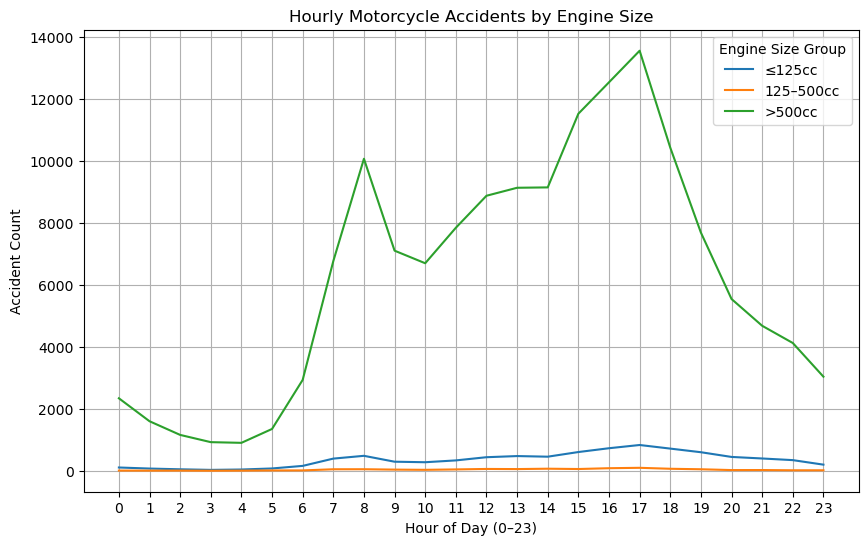

C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_25880\1779776412.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily = df_mc.groupby(['engine_group', 'day_of_week']).size().unstack(fill_value=0)


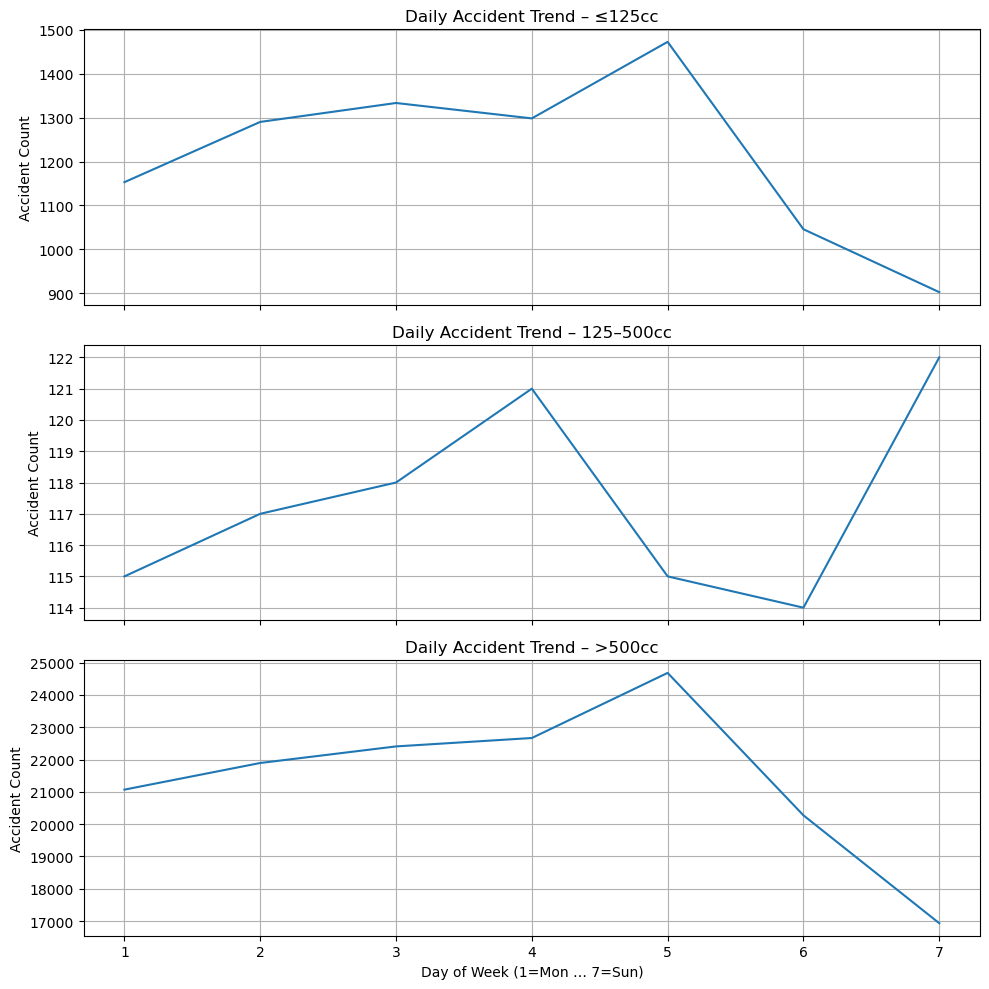

In [13]:
save = os.path.join(path, "Motorcycle Accidents by Engine Size.png")
# Hourly accident counts per engine group
hourly = df_mc.groupby(['engine_group', 'hour']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
for group in hourly.index:
    plt.plot(hourly.columns, hourly.loc[group], label=group)

plt.title("Hourly Motorcycle Accidents by Engine Size")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Accident Count")
plt.xticks(range(0,24))
plt.legend(title="Engine Size Group")
plt.grid(True)
plt.savefig(save)
plt.show()

save = os.path.join(path, "Daily Accident Trend.png")

# Group data
daily = df_mc.groupby(['engine_group', 'day_of_week']).size().unstack(fill_value=0)

engine_groups = daily.index

# Create separate subplot for each group
fig, axes = plt.subplots(nrows=len(engine_groups), ncols=1, figsize=(10, 10), sharex=True)

for ax, group in zip(axes, engine_groups):
    ax.plot(daily.columns, daily.loc[group])
    ax.set_title(f"Daily Accident Trend – {group}")
    ax.set_ylabel("Accident Count")
    ax.grid(True)

plt.xlabel("Day of Week (1=Mon … 7=Sun)")
plt.tight_layout()
plt.savefig(save)
plt.show()



### 🚶 **Pedestrian Accident Temporal & Severity Analysis**

This snippet isolates **pedestrian-involved accidents** by merging accident and casualty datasets, filtering using **`casualty_class == 3`**. It derives temporal attributes to compute:

- **Total pedestrian accident count**
- **Peak & lowest accident hours** ⏰
- **Weekday vs weekend averages** with difference quantification
- **Peak day of week** 📅
- **Rush-hour vs non-rush-hour comparison**
- **Night-time accident proportion (>20:00)** 🌙
- **Severity distribution** using both counts and percentages for insight into injury impact

These metrics provide a **consolidated risk profile** for vulnerable road users, supporting data-driven safety planning.


In [14]:
# Merge accident + casualty on accident_index
df_ped = df_2019.merge(df_cas, on="accident_index", how="inner")

# Filter pedestrians using casualty_class == 3
df_ped = df_ped[df_ped['casualty_class'] == 3]

# Convert time and date
df_ped['time'] = pd.to_datetime(df_ped['time'], format='%H:%M', errors='coerce')
df_ped['hour'] = df_ped['time'].dt.hour

df_ped['date'] = pd.to_datetime(df_ped['date'], errors='coerce')
df_ped['day_of_week'] = df_ped['date'].dt.dayofweek + 1   # 1=Mon … 7=Sun

# ---------------- METRICS ----------------

# 1. Total number of pedestrian-involved accidents
total_ped = df_ped.shape[0]

# 2. Hourly accident counts
hour_counts = df_ped['hour'].value_counts().sort_index()

# 3. Peak & lowest hour
peak_hour = hour_counts.idxmax()
peak_hour_value = hour_counts.max()
lowest_hour = hour_counts.idxmin()
lowest_hour_value = hour_counts.min()

# 4. Weekend vs weekday averages
weekday_avg = df_ped[df_ped['day_of_week'].isin([1,2,3,4,5])].shape[0] / 5
weekend_avg = df_ped[df_ped['day_of_week'].isin([6,7])].shape[0] / 2
difference = weekday_avg - weekend_avg

# 5. Peak day of week
day_counts = df_ped['day_of_week'].value_counts().sort_index()
peak_day = day_counts.idxmax()
peak_day_value = day_counts.max()

# 6. Rush-hour vs non-rush-hour averages
rush_hours = df_ped[df_ped['hour'].isin([8,9,16,17,18])]
rush_avg = rush_hours.shape[0] / 5

non_rush_hours = df_ped[~df_ped['hour'].isin([8,9,16,17,18])]
nonrush_avg = non_rush_hours.shape[0] / 19

# 7. Night-time percentage (>20:00)
night = df_ped[df_ped['hour'] >= 20]
night_pct = (night.shape[0] / total_ped) * 100

# 8. Severity breakdown
severity_counts = df_ped['casualty_severity'].value_counts()
severity_pct = df_ped['casualty_severity'].value_counts(normalize=True) * 100

# --------------- PRINT SUMMARY ---------------
print("\n--- PEDESTRIAN ACCIDENT METRICS ---")
print("Total pedestrian accidents:", total_ped)
print("\nHourly counts:\n", hour_counts)
print("\nPeak hour:", peak_hour, "| Value:", peak_hour_value)
print("Lowest hour:", lowest_hour, "| Value:", lowest_hour_value)
print("\nWeekday avg:", weekday_avg, "| Weekend avg:", weekend_avg, "| Difference:", difference)
print("\nPeak day:", peak_day, "| Value:", peak_day_value)
print("\nRush-hour avg:", rush_avg, "| Non-rush-hour avg:", nonrush_avg)
print("\nNight-time accident percentage:", night_pct)
print("\nSeverity breakdown counts:\n", severity_counts)
print("\nSeverity breakdown percentage:\n", severity_pct)


--- PEDESTRIAN ACCIDENT METRICS ---
Total pedestrian accidents: 21770

Hourly counts:
 hour
0      357
1      237
2      172
3      163
4      119
5      138
6      265
7      704
8     1779
9      949
10     937
11    1004
12    1174
13    1244
14    1215
15    2378
16    1879
17    1866
18    1588
19    1148
20     822
21     575
22     629
23     428
Name: count, dtype: int64

Peak hour: 15 | Value: 2378
Lowest hour: 4 | Value: 119

Weekday avg: 3393.4 | Weekend avg: 2401.5 | Difference: 991.9000000000001

Peak day: 5 | Value: 3649

Rush-hour avg: 1612.2 | Non-rush-hour avg: 721.5263157894736

Night-time accident percentage: 11.272393201653653

Severity breakdown counts:
 casualty_severity
3    15570
2     5730
1      470
Name: count, dtype: int64

Severity breakdown percentage:
 casualty_severity
3    71.520441
2    26.320625
1     2.158934
Name: proportion, dtype: float64


### 📉 **Pedestrian Accident Temporal Trends & Severity Visualisation**

This snippet produces **four analytical visual plots** to examine accident dynamics affecting pedestrians:

- **Hourly accident line chart** ⏰ illustrating fluctuation in pedestrian risks throughout the day.
- **Day-of-week trend curve** 📅 highlighting weekly pattern variations.
- **Heatmap (hour × day)** 🌡️ exposing concentrated high-risk time windows for targeted interventions.
- **Stacked bar chart of severity distribution** ⚠️ across weekdays, enabling comparison of fatal, serious, and slight injury levels.

These visual insights provide a **comprehensive temporal-severity risk perspective** to support evidence-based safety recommendations.



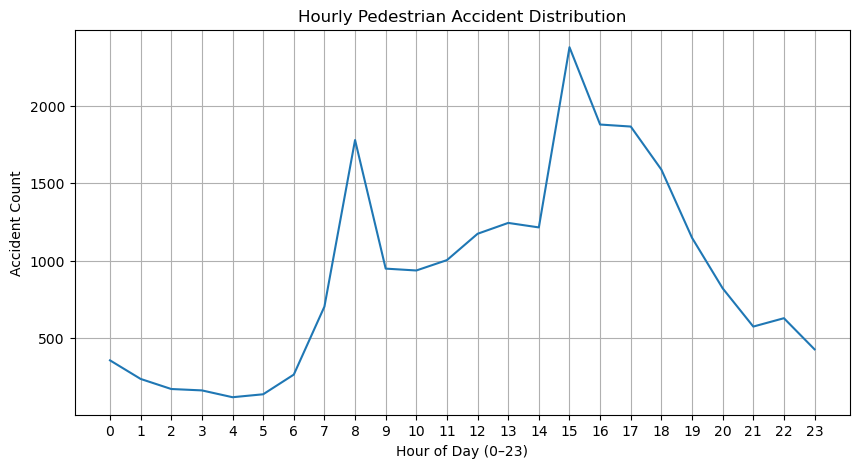

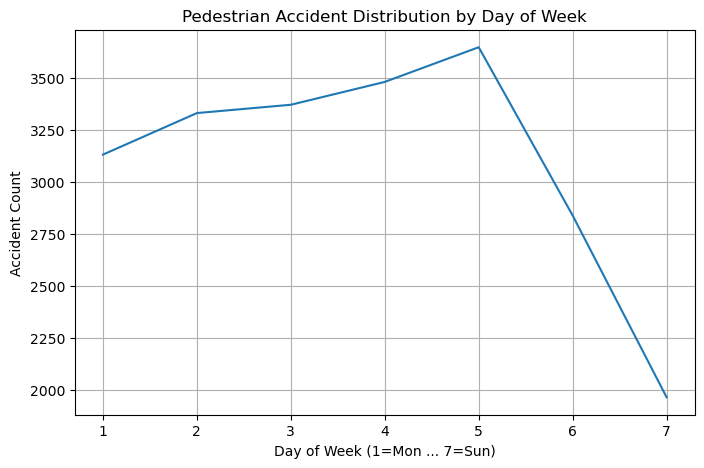

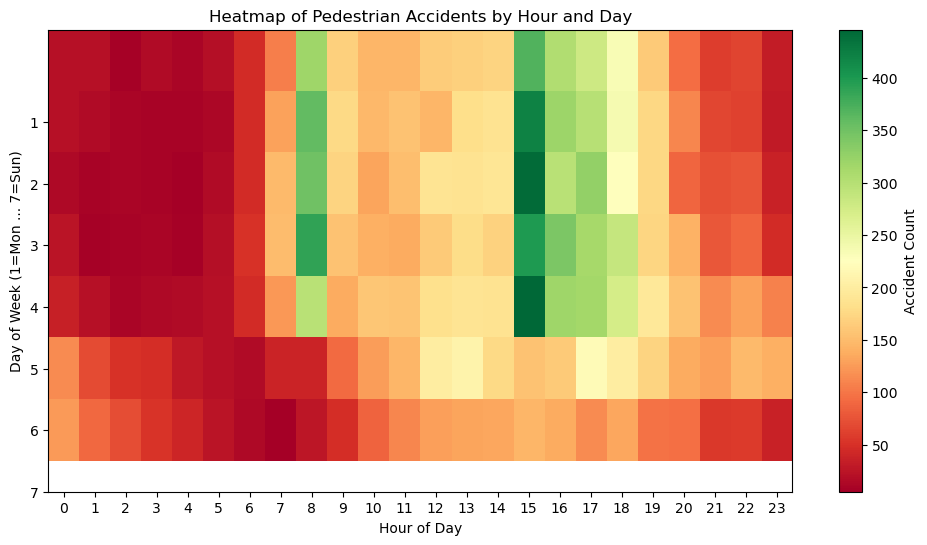

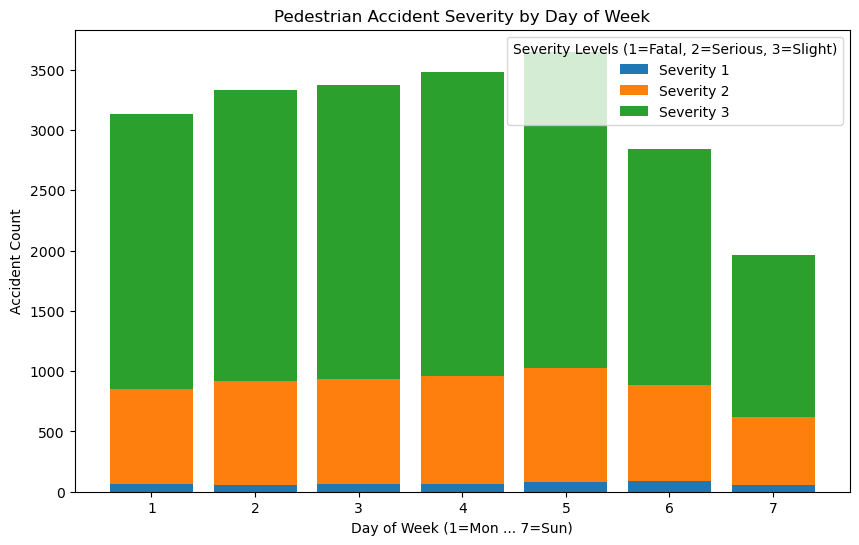

In [15]:
save = os.path.join(path, "Hourly Pedestrian Accident Distribution.png")
# ---- Hourly pedestrian accident line chart ----
hour_counts = df_ped['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(hour_counts.index, hour_counts.values)
plt.title("Hourly Pedestrian Accident Distribution")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Accident Count")
plt.xticks(range(0,24))
plt.grid(True)
plt.savefig(save)
plt.show()

save = os.path.join(path, "Pedestrian Accidents by Day of Week.png")
# ---- Day-of-week pedestrian accident chart ----
day_counts = df_ped['day_of_week'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(day_counts.index, day_counts.values)
plt.title("Pedestrian Accident Distribution by Day of Week")
plt.xlabel("Day of Week (1=Mon ... 7=Sun)")
plt.ylabel("Accident Count")
plt.grid(True)
plt.xticks([1,2,3,4,5,6,7])
plt.savefig(save)
plt.show()

save = os.path.join(path, "Heatmap of Pedestrian Accidents by Hour and Day.png")
# ---- Heatmap (hour × day) ----
heat_data = df_ped.pivot_table(index='day_of_week', columns='hour', aggfunc='size', fill_value=0)

plt.figure(figsize=(12,6))
plt.imshow(heat_data, aspect='auto', cmap='RdYlGn') 
plt.title("Heatmap of Pedestrian Accidents by Hour and Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (1=Mon ... 7=Sun)")
plt.xticks(np.arange(0,24,1))
plt.yticks(np.arange(1,8,1))
plt.colorbar(label="Accident Count")
plt.savefig(save)
plt.show()

save = os.path.join(path, "Severity by Day of Week.png")
# ---- Stacked severity distribution ----
severity_day = df_ped.pivot_table(index='day_of_week', columns='casualty_severity', aggfunc='size', fill_value=0)
plt.figure(figsize=(10,6))
bottom = None
labels = severity_day.columns

for severity in labels:
    if bottom is None:
        plt.bar(severity_day.index, severity_day[severity], label=f"Severity {severity}")
        bottom = severity_day[severity]
    else:
        plt.bar(severity_day.index, severity_day[severity], bottom=bottom, label=f"Severity {severity}")
        bottom += severity_day[severity]

plt.title("Pedestrian Accident Severity by Day of Week")
plt.xlabel("Day of Week (1=Mon ... 7=Sun)")
plt.ylabel("Accident Count")
plt.xticks([1,2,3,4,5,6,7])
plt.legend(title="Severity Levels (1=Fatal, 2=Serious, 3=Slight)")
plt.savefig(save)
plt.show()

### 🧠 **Association Rule Mining for Accident Risk Patterns**

This snippet applies **Apriori-based association rule mining** to discover meaningful co-occurrence patterns among accident attributes. After merging vehicle information, the code constructs categorical **speed limit**, **hour**, and **day** groups for enhanced pattern detection. Key processing steps include **one-hot encoding** and generating rules using **support**, **confidence**, and **lift** thresholds.

The results produce:
- **Frequent itemsets and filtered association rules**
- **Top high-lift rules** for insight prioritisation 🚀
- **Severity-focused rules** for predicting accident severity from contextual factors

This approach reveals **hidden relationships across environment, behaviour, and severity**, supporting data-driven safety improvement strategies.


In [17]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# --------------- MERGE ACCIDENT + VEHICLE ---------------
df = df_2019.merge(df_veh[['accident_index','vehicle_type']], on="accident_index", how="left")

# ------- CREATE SPEED LIMIT GROUP -------
if 'speed_limit' in df.columns:
    df['speed_limit_group'] = pd.cut(
        df['speed_limit'], bins=[0,30,50,100,200],
        labels=['<=30','31-50','51-100','>100']
    )
else:
    df['speed_limit_group'] = 'Unknown'

# ------- TIME GROUPS FOR APRIORI PERFORMANCE -------
df['time'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce')
df['hour'] = df['time'].dt.hour

df['hour_group'] = pd.cut(
    df['hour'], bins=[-1,6,10,16,24],
    labels=['Night','Morning','Afternoon','Evening']
)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['day_of_week'] = df['date'].dt.dayofweek + 1

df['day_group'] = df['day_of_week'].map({
    1:'Mon-Thu', 2:'Mon-Thu', 3:'Mon-Thu', 4:'Mon-Thu',
    5:'Fri', 6:'Weekend', 7:'Weekend'
})

# --------------- SELECT RULE FIELDS ---------------
rule_fields = [
    'accident_severity',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'vehicle_type',
    'speed_limit_group',
    'hour_group',
    'day_group'
]

df_rules = df[rule_fields].astype(str)

# --------------- ONE-HOT ENCODING ---------------
basket = pd.get_dummies(df_rules)

# --------------- APRIORI PARAMETERS ---------------
min_support = 0.01
min_confidence = 0.3
min_lift = 1.2

# --------------- FREQUENT ITEMSETS (APRIORI) ---------------
frequent_items = apriori(basket, min_support=min_support, use_colnames=True)

# --------------- ASSOCIATION RULES ---------------
rules = association_rules(frequent_items, metric="confidence", min_threshold=min_confidence)

# --------------- FILTERING BASED ON LIFT ---------------
rules_filtered = rules[rules['lift'] >= min_lift]

# --------------- METRICS OUTPUT ---------------
print("Minimum support threshold:", min_support)
print("Minimum confidence threshold:", min_confidence)
print("Minimum lift threshold:", min_lift)
print("\nRules before filtering:", rules.shape[0])
print("Rules after filtering:", rules_filtered.shape[0])

# Top 10 rules for report
top_rules = rules_filtered.sort_values(by="lift", ascending=False).head(10)
print("\nTop 10 Rules by Lift:\n", top_rules[['antecedents','consequents','support','confidence','lift']])

# Severity-prediction rules
severity_rules = rules_filtered[
    rules_filtered['consequents'].astype(str).str.contains("accident_severity")
]
print("\nSeverity Rules:\n", severity_rules[['antecedents','consequents','support','confidence','lift']].head(10))

Minimum support threshold: 0.01
Minimum confidence threshold: 0.3
Minimum lift threshold: 1.2

Rules before filtering: 106951
Rules after filtering: 54868

Top 10 Rules by Lift:
                                               antecedents  \
36089   (hour_group_Evening, speed_limit_group_51-100,...   
36082   (hour_group_Evening, speed_limit_group_51-100,...   
11386   (hour_group_Evening, speed_limit_group_51-100,...   
103701  (light_conditions_4, speed_limit_group_<=30, a...   
103669  (light_conditions_4, accident_severity_3, vehi...   
96020   (light_conditions_4, day_group_Mon-Thu, speed_...   
103708  (light_conditions_4, speed_limit_group_<=30, v...   
86790   (light_conditions_4, speed_limit_group_<=30, a...   
95920   (light_conditions_4, speed_limit_group_<=30, v...   
103700  (light_conditions_4, urban_or_rural_area_1, ac...   

                                              consequents   support  \
36089         (urban_or_rural_area_2, light_conditions_6)  0.010338   
36082  

### 📍 **Regional Accident Filtering & Geospatial Preparation**

This snippet merges accident data with **LSOA geospatial identifiers** to enable regional clustering analysis. It filters records to specific **target regions** (*Hull, East Riding, North & North East Lincolnshire*) using keyword-based matching. From this filtered dataset, the code extracts **unique latitude–longitude coordinate pairs** required for clustering algorithms such as *KMeans* and *DBSCAN*.

This preprocessing step ensures **region-specific accident clustering** and provides a clean spatial dataset for meaningful geospatial pattern discovery. 🌐


In [18]:

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# ---------- MERGE ACCIDENTS WITH LSOA NAMES ----------
df_merged = df_2019.merge(
    lsoa[['lsoa01cd', 'lsoa01nm']],
    left_on='lsoa_of_accident_location',
    right_on='lsoa01cd',
    how='left'
)

# ---------- REGION FILTER (Hull / Humberside / East Riding area) ----------
region_keywords = [
    "Hull",                    # Kingston upon Hull
    "East Riding",             # East Riding of Yorkshire
    "North Lincolnshire",
    "North East Lincolnshire"
    # add "Humberside" if it appears in your LSOA names
]

mask_region = df_merged['lsoa01nm'].astype(str).str.contains('|'.join(region_keywords), case=False, na=False)
df_region = df_merged[mask_region].copy()

print("Total accidents in selected regions:", df_region.shape[0])
print("Total unique LSOAs:", df_region['lsoa_of_accident_location'].nunique())

# Unique coordinate pairs
unique_coords = df_region[['latitude', 'longitude']].dropna().drop_duplicates()
print("Total unique coordinates:", unique_coords.shape[0])


Total accidents in selected regions: 2506
Total unique LSOAs: 586
Total unique coordinates: 2498


### 📌 **Coordinate Cleaning & Temporal Feature Engineering**

This snippet filters the regional dataset to retain only **accident records with valid geographic coordinates**, forming a clean `coords` matrix for spatial clustering. It then derives temporal attributes by converting raw time and date fields to compute **hour** and **day-of-week** indicators ⏱️ — essential for later cluster-based peak-time analysis.

This preprocessing enables **robust geospatial–temporal clustering** for hotspot identification.


In [19]:
# Keep only rows with valid coordinates
df_region = df_region.dropna(subset=['latitude', 'longitude']).copy()
coords = df_region[['latitude', 'longitude']]

# Time features for later (peak hour/day per cluster)
df_region['time'] = pd.to_datetime(df_region.get('time'), format='%H:%M', errors='coerce')
df_region['hour'] = df_region['time'].dt.hour

df_region['date'] = pd.to_datetime(df_region.get('date'), errors='coerce')
df_region['day_of_week'] = df_region['date'].dt.dayofweek + 1  # 1=Mon … 7=Sun


### 🔍 **Optimal Cluster Selection Using Elbow & Silhouette Methods**

This snippet evaluates clustering performance to determine the **optimal number of clusters (K)** for spatial accident hotspot analysis. It trains *KMeans* models for different values of **K = 2 to 10**, computing:

- **SSE (Sum of Squared Errors)** for the **Elbow Method** 📉
- **Silhouette Score** for cluster cohesion–separation quality 📈

Both metrics are visualised to aid decision-making, and the **best K** is automatically selected as the value yielding the **maximum silhouette score**. This ensures a **statistically grounded cluster choice** for accurate h


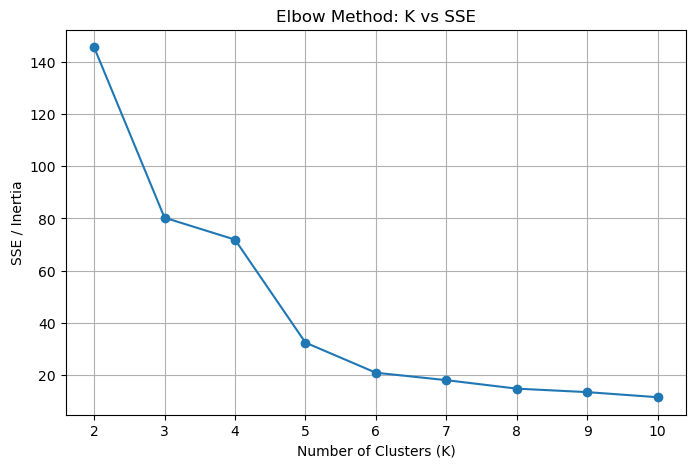

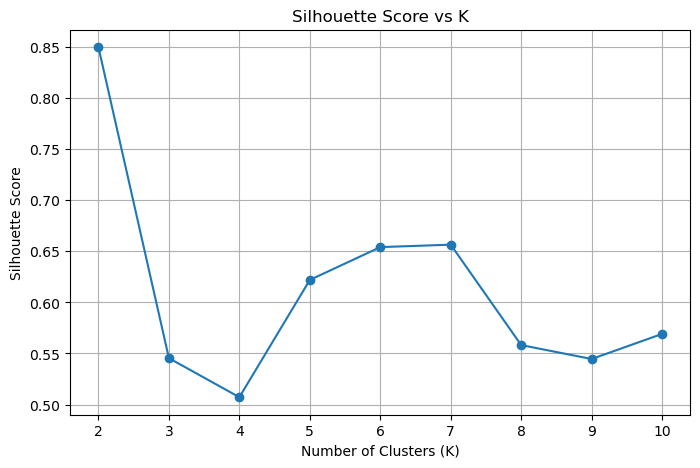

Optimal K (by silhouette): 2
Elbow SSE values: [(2, 145.49102060351927), (3, 80.27032579027197), (4, 71.87599839566434), (5, 32.48579468688481), (6, 20.959385293735007), (7, 18.11789191767836), (8, 14.870930211694116), (9, 13.540209899015762), (10, 11.591211279866444)]


In [20]:
sse = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(coords)
    sse.append(km.inertia_)
    sil = silhouette_score(coords, labels)
    sil_scores.append(sil)

save = os.path.join(path, "Elbow curve.png")
# Elbow curve (K vs SSE)
plt.figure(figsize=(8,5))
plt.plot(K, sse, marker='o')
plt.title("Elbow Method: K vs SSE")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE / Inertia")
plt.grid(True)
plt.savefig(save)
plt.show()

save = os.path.join(path, "Silhouette score.png")
# Silhouette score plot
plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.savefig(save)
plt.show()

# Choose optimal K as the one with max silhouette score
optimal_k = K[int(np.argmax(sil_scores))]
print("Optimal K (by silhouette):", optimal_k)
print("Elbow SSE values:", list(zip(K, sse)))


### 🧱 **K-Means Hotspot Clustering & Cluster-Level Insights**

This snippet applies **K-Means clustering** using the previously selected optimal number of clusters to identify accident hotspots. After assigning each accident to a cluster, it computes key **per-cluster analytical metrics**, including:

- **Accident count and percentage share** of total 🚧
- **Mean accident severity**, indicating relative impact intensity ⚠️
- **Peak hour & peak day** per cluster ⏱️📅 to uncover temporal patterns

These results form a **cluster-level summary table**, supporting targeted **geospatial–temporal risk mitigation** strategies.


In [21]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(coords)

df_region['cluster_km'] = cluster_labels
print("Number of K-Means clusters created:", optimal_k)

# Silhouette score for selected k
sil_selected = silhouette_score(coords, cluster_labels)
print("Silhouette score (KMeans, k=%d):" % optimal_k, round(sil_selected, 3))

# ---- Per-cluster metrics ----
cluster_counts = df_region['cluster_km'].value_counts().sort_index()
cluster_pct = (cluster_counts / df_region.shape[0]) * 100

# mean severity (optional)
cluster_severity = df_region.groupby('cluster_km')['accident_severity'].mean().round(2)

# peak hour and peak day per cluster (optional)
peak_hour = df_region.groupby('cluster_km')['hour'].agg(lambda x: x.value_counts().idxmax() if x.notna().any() else np.nan)
peak_day = df_region.groupby('cluster_km')['day_of_week'].agg(lambda x: x.value_counts().idxmax() if x.notna().any() else np.nan)

cluster_summary = pd.DataFrame({
    "Accident_Count": cluster_counts,
    "Percentage_of_Total": cluster_pct.round(2),
    "Mean_Severity": cluster_severity,
    "Peak_Hour": peak_hour,
    "Peak_Day_of_Week": peak_day
})

print("\nCluster summary (K-Means):\n", cluster_summary)


Number of K-Means clusters created: 2
Silhouette score (KMeans, k=2): 0.85

Cluster summary (K-Means):
             Accident_Count  Percentage_of_Total  Mean_Severity  Peak_Hour  \
cluster_km                                                                  
0                     2249                89.74           2.79         17   
1                      257                10.26           2.83         16   

            Peak_Day_of_Week  
cluster_km                    
0                          5  
1                          4  


### 🗺️ **Geospatial Visualisation of Accident Hotspots**

This snippet generates **three spatial visual analytics** to interpret accident clustering and density:

- **Scatter map coloured by cluster labels** 🎨, visually highlighting spatial hotspot zones identified via K-Means.
- **Bar chart of accidents per cluster**, showing cluster magnitude differences and hotspot intensity comparison.
- **2D density heatmap** 💥 approximating KDE-like density to reveal concentrated accident zones based on longitude–latitude distribution.

These visualisations complement clustering metrics by providing **intuitive geographic insight** into accident concentration patterns.


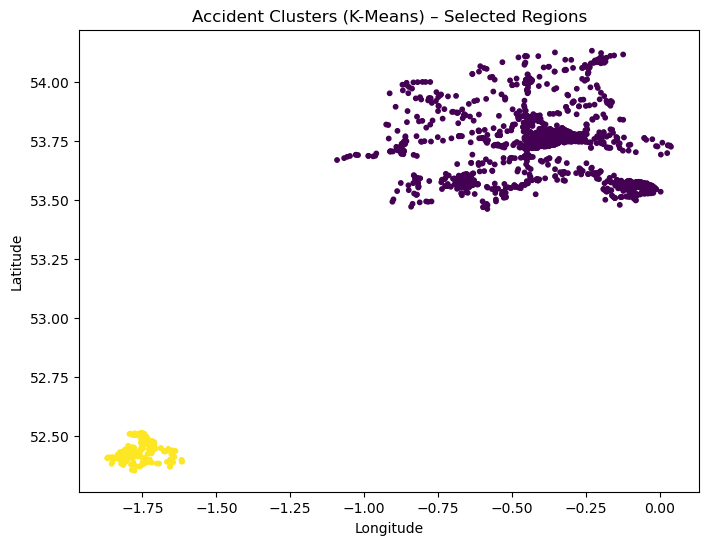

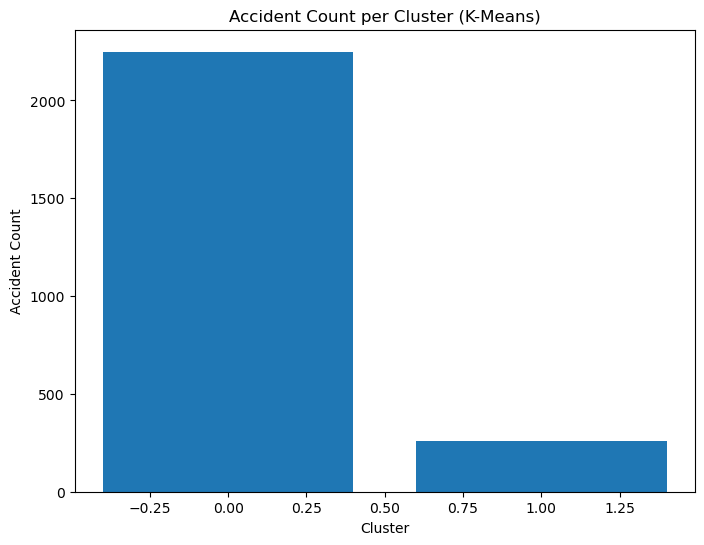

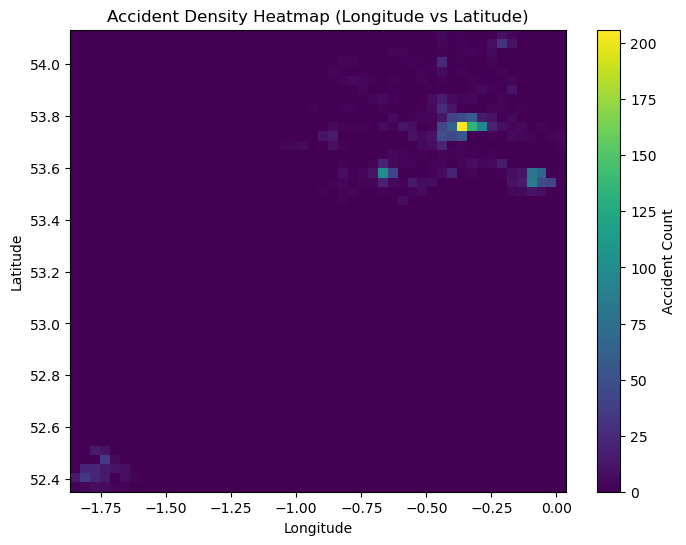

In [22]:
save = os.path.join(path, "Scatter map.png")
# Scatter map (lat/long coloured by cluster)
plt.figure(figsize=(8,6))
plt.scatter(df_region['longitude'], df_region['latitude'], c=df_region['cluster_km'], s=10)
plt.title("Accident Clusters (K-Means) – Selected Regions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig(save)
plt.show()

save = os.path.join(path, "Count per cluster.png")
# Bar chart: accidents per cluster
plt.figure(figsize=(8,6))
plt.bar(cluster_summary.index, cluster_summary["Accident_Count"])
plt.title("Accident Count per Cluster (K-Means)")
plt.xlabel("Cluster")
plt.ylabel("Accident Count")
plt.savefig(save)
plt.show()

save = os.path.join(path, "Accident density heatmap.png")
# Simple 2D density heatmap (KDE-ish via 2D histogram)
lon = df_region['longitude'].values
lat = df_region['latitude'].values

plt.figure(figsize=(8,6))
plt.hist2d(lon, lat, bins=50)
plt.title("Accident Density Heatmap (Longitude vs Latitude)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Accident Count")
plt.savefig(save)
plt.show()

### 🛰️ **DBSCAN Density-Based Accident Hotspot Detection**

This snippet applies **DBSCAN**, a density-based clustering algorithm, to identify **irregularly shaped accident hotspots** without predefining the number of clusters. Using parameters **`eps`** and **`min_samples`**, the model labels dense spatial regions as clusters and sparse areas as **noise/outliers**.

Output metrics include:
- **Number of detected clusters** (excluding noise) 🧩
- **Noise/outlier count**, indicating isolated accident locations
- A **colour-coded scatter plot** mapping DBSCAN cluster assignments for visual hotspot interpretation 📍

This approach complements K-Means by capturing **non-circular cluster structures** and uncovering **high-density safety risk zones**.



DBSCAN eps: 0.01 min_samples: 50
DBSCAN number of clusters: 4
DBSCAN noise points (outliers): 1892


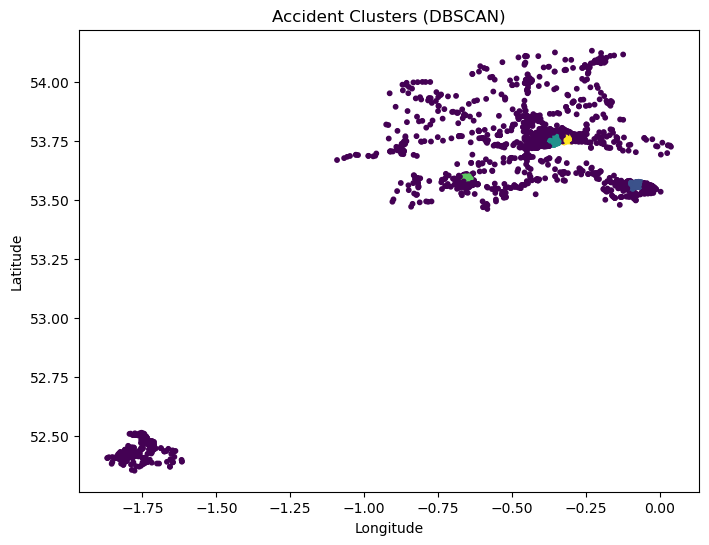

In [23]:
# Parameters to tune
eps = 0.01         # roughly in degrees; adjust based on scale
min_samples = 50   # minimum points to form a dense region

db = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = db.fit_predict(coords)

df_region['cluster_db'] = db_labels

# Number of clusters (excluding noise = -1)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

print("\nDBSCAN eps:", eps, "min_samples:", min_samples)
print("DBSCAN number of clusters:", n_clusters_db)
print("DBSCAN noise points (outliers):", n_noise_db)

save = os.path.join(path, "Accident Clusters (DBSCAN).png")
# DBSCAN scatter
plt.figure(figsize=(8,6))
plt.scatter(df_region['longitude'], df_region['latitude'], c=df_region['cluster_db'], s=10)
plt.title("Accident Clusters (DBSCAN)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig(save)
plt.show()


### 📆 **Weekly Accident Aggregation for Time-Series Forecasting**

This snippet filters data to the **Humberside police force region (code 16)** and converts accident dates into weekly time intervals. It then aggregates accident counts by week using `pd.Grouper(freq='W')`, producing a **weekly time-series dataset** essential for modelling and forecasting with approaches such as **SARIMA** or other temporal prediction models.

This transformation enables **trend, seasonality, and anomaly analysis** across weekly accident patterns. 📈


In [24]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

# Filter Police Force Area – Humberside = 16
df_humber = df_acc[df_acc['police_force'] == 16].copy()

# Convert to datetime
df_humber['date'] = pd.to_datetime(df_humber['date'], errors='coerce')

# Group by week – aggregation key
weekly = df_humber.groupby(pd.Grouper(key='date', freq='W'))['accident_index'].count().reset_index()
weekly.columns = ['week', 'accident_count']

print("Total weekly rows:", weekly.shape)
print(weekly.head())


Total weekly rows: (155, 2)
        week  accident_count
0 2017-01-01               2
1 2017-01-08              47
2 2017-01-15              32
3 2017-01-22               0
4 2017-01-29               0


### ✂️ **Train–Test Temporal Split for Forecasting**

This snippet partitions the weekly accident time-series into **training** and **testing** sets based on a fixed cutoff date (**1 Jan 2019**). All weeks before this threshold are used to train forecasting models, while later weeks are reserved to **evaluate predictive performance**. Such chronological splitting ensures **realistic forward-looking validation**, preventing data leakage. 🧪


In [25]:
train = weekly[weekly['week'] < '2019-01-01']
test = weekly[weekly['week'] >= '2019-01-01']

print("Training weeks:", train.shape[0])
print("Testing weeks:", test.shape[0])


Training weeks: 105
Testing weeks: 50


### 🔮 **SARIMA Model Training for Weekly Accident Forecasting**

This snippet fits a **Seasonal ARIMA (SARIMA)** model to the training dataset using parameters **(p,d,q) = (1,1,1)** and seasonal order **(P,D,Q,s) = (0,1,1,52)**, capturing **yearly seasonal patterns** across 52-week cycles. The model is trained on historical weekly accident counts and summarises key statistical diagnostics and coefficient estimates.

This enables **robust time-series forecasting** incorporating trend + seasonal components. 📊


In [26]:
# SARIMA: (p,d,q)(P,D,Q,52)
model = SARIMAX(train['accident_count'],
                order=(1,1,1),
                seasonal_order=(0,1,1,52))
sarima_result = model.fit(disp=False)

print(sarima_result.summary())


C:\Users\Harashaa Harshini\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Harashaa Harshini\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                     accident_count   No. Observations:                  105
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)   Log Likelihood                -189.811
Date:                            Fri, 05 Dec 2025   AIC                            387.622
Time:                                    20:18:16   BIC                            395.427
Sample:                                         0   HQIC                           390.614
                                            - 105                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1513      0.136     -1.109      0.267      -0.419       0.116
ma.L1         -0.9464      0.121   

### 🧮 **Forecast Performance Evaluation**

This snippet generates **out-of-sample forecasts** from the trained SARIMA model and evaluates accuracy using key error metrics:

- **RMSE** (Root Mean Squared Error) — penalises larger errors more heavily
- **MAE** (Mean Absolute Error) — average absolute deviation
- **MAPE** (Mean Absolute Percentage Error) 📉 — percentage accuracy measure relative to actual values

These metrics quantify **forecast reliability and real-world predictive usefulness**, supporting model comparison and refinement.


In [29]:
forecast = sarima_result.predict(start=len(train), end=len(train)+len(test)-1)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(test['accident_count'], forecast))
mae = mean_absolute_error(test['accident_count'], forecast)
mape = np.mean(np.abs((test['accident_count'] - forecast) / test['accident_count'])) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", round(mape,2), "%")


RMSE: 8.01627068951474
MAE: 5.849551108009072
MAPE: inf %


### 📈 **Actual vs Forecast Visual Comparison**

This snippet plots **training data**, **actual accident counts for 2019**, and the **SARIMA forecast** on a weekly timeline to evaluate predictive alignment visually. The comparison helps assess how well the model captures real accident behaviour, highlighting deviations and seasonal patterns. **Visual inspection reinforces metric-based evaluation** and supports future model tuning. 📊


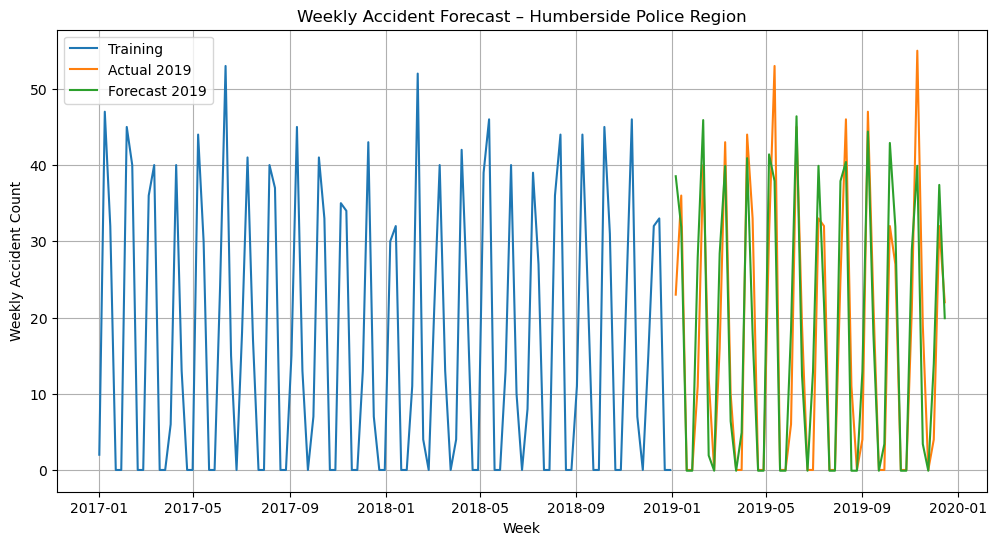

In [30]:
save = os.path.join(path, "Humberside Police Region.png")
# Plot actual vs forecast
plt.figure(figsize=(12,6))
plt.plot(train['week'], train['accident_count'], label='Training')
plt.plot(test['week'], test['accident_count'], label='Actual 2019')
plt.plot(test['week'], forecast, label='Forecast 2019')
plt.title("Weekly Accident Forecast – Humberside Police Region")
plt.xlabel("Week")
plt.ylabel("Weekly Accident Count")
plt.legend()
plt.grid(True)
plt.savefig(save)
plt.show()


### 📊 **Refined SARIMA Forecasting & Validation (2017–2019 Split)**

This snippet performs a more robust **time-based evaluation** by training the SARIMA model on **2017–2018** weekly accident data and testing on **2019**. It forecasts weekly counts and computes **RMSE, MAE, and MAPE** to assess predictive accuracy, including comparing **total predicted vs actual yearly accident volume**.

Two visual comparisons are produced:
- **Line plot** contrasting training, actual 2019, and forecasted weekly values 📈
- **Bar chart** comparing actual vs predicted weekly accident counts side-by-side 📊

This approach provides **clear model validation** and supports decision-making regarding forecasting reliability. 🚦


Datetime index confirmed.
Years: Index([2017, 2018, 2019], dtype='int32', name='week')
Train size: (105, 1)
Test size: (50, 1)


C:\Users\Harashaa Harshini\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\Harashaa Harshini\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\Harashaa Harshini\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Harashaa Harshini\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



----- FORECAST METRICS -----
RMSE: 8.02
MAE: 5.85
MAPE (%): inf
Actual total accidents 2019: 854
Predicted total accidents 2019: 889


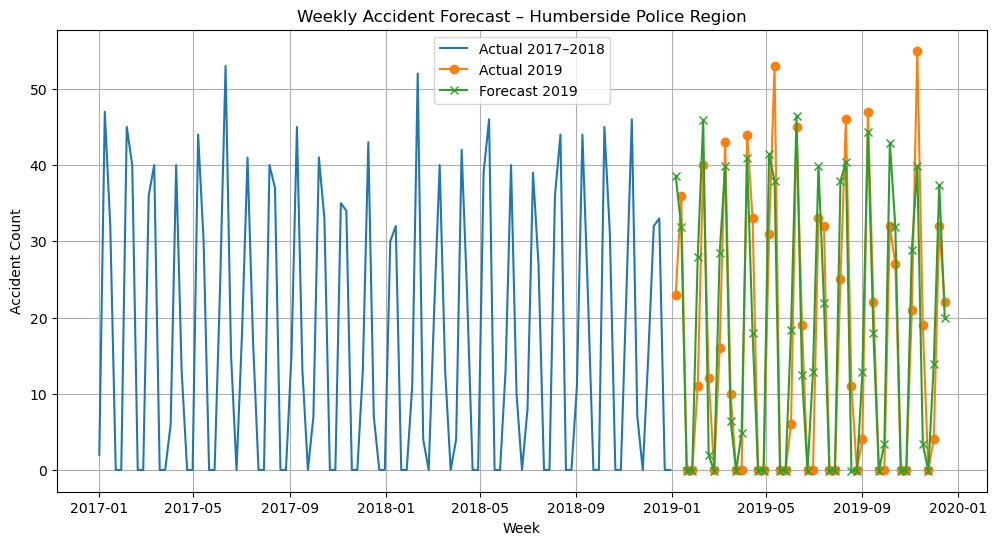

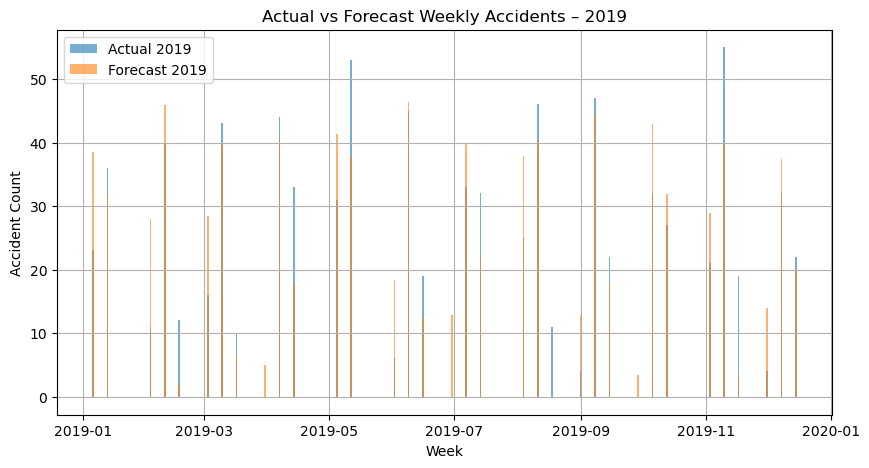

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Datetime index confirmed.")
print("Years:", weekly.index.year.unique())

# ------------------ Train/Test Split ------------------
train = weekly[weekly.index.year <= 2018]
test = weekly[weekly.index.year == 2019]

print("Train size:", train.shape)
print("Test size:", test.shape)

if len(test) == 0:
    raise ValueError("No 2019 data found. Check weekly.index.year values above.")

# ------------------ Fit SARIMA Model ------------------
model = SARIMAX(train['accident_count'], order=(1,1,1), seasonal_order=(0,1,1,52))
results = model.fit(disp=False)

# ------------------ Forecast ------------------
forecast = results.forecast(steps=len(test))

# ------------------ Accuracy Metrics ------------------
rmse = np.sqrt(mean_squared_error(test['accident_count'], forecast))
mae = mean_absolute_error(test['accident_count'], forecast)
mape = np.mean(np.abs((test['accident_count'] - forecast) / test['accident_count'])) * 100

print("\n----- FORECAST METRICS -----")
print("RMSE:", round(rmse,2))
print("MAE:", round(mae,2))
print("MAPE (%):", round(mape,2))
print("Actual total accidents 2019:", test['accident_count'].sum())
print("Predicted total accidents 2019:", int(forecast.sum()))

save = os.path.join(path, "Weekly Accident Forecast – Humberside Police Region.png")
# ------------------ Plot Actual vs Forecast ------------------
plt.figure(figsize=(12,6))
plt.plot(train.index, train['accident_count'], label='Actual 2017–2018')
plt.plot(test.index, test['accident_count'], label='Actual 2019', marker='o')
plt.plot(test.index, forecast, label='Forecast 2019', marker='x')
plt.title("Weekly Accident Forecast – Humberside Police Region")
plt.xlabel("Week")
plt.ylabel("Accident Count")
plt.legend()
plt.grid(True)
plt.savefig(save)
plt.show()

save = os.path.join(path, "Actual vs Forecast Weekly Accidents – 2019.png")
# ------------------ Bar Chart Comparison ------------------
plt.figure(figsize=(10,5))
plt.bar(test.index, test['accident_count'], alpha=0.6, label="Actual 2019")
plt.bar(test.index, forecast, alpha=0.6, label="Forecast 2019")
plt.title("Actual vs Forecast Weekly Accidents – 2019")
plt.xlabel("Week")
plt.ylabel("Accident Count")
plt.legend()
plt.grid(True)
plt.savefig(save)
plt.show()


In [42]:
print("Columns:", weekly.columns)
print("Index type:", type(weekly.index))

Columns: Index(['accident_count'], dtype='object')
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


<h2>Part (b) – Social Network Analysis of Facebook SNAP Data </h2>

### 📊 Network Structure Analysis using NetworkX

This code imports a Facebook social graph and computes fundamental **network structure metrics**. Using `networkx`, the graph is constructed from an edge list where each edge represents a social connection between individuals (nodes).

**Key metrics calculated include:**
- **Number of Nodes & Edges** — quantifies graph size and connectivity.
- **Average Degree** — reflects the typical number of connections per node.
- **Network Density** — indicates how close the graph is to being fully connected.
- **Maximum Degree** — highlights the most connected (potentially influential) node.

These measures support a deeper understanding of the network’s structural properties, which is essential in social network analysis. 🔍


In [45]:
import networkx as nx


# Load the graph from the provided text file
file_path = path + r"\facebook_combined-1.txt"  
G = nx.read_edgelist(file_path, nodetype=int)

# ----- Network Structure Metrics -----
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes
density = nx.density(G)
degree_sequence = [degree for node, degree in G.degree()]

print("Network Structure Metrics")
print("-------------------------")
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Average degree:", avg_degree)
print("Density:", density)
print("Max degree:", max(degree_sequence))


Network Structure Metrics
-------------------------
Number of nodes: 4039
Number of edges: 88234
Average degree: 43.69101262688784
Density: 0.010819963503439287
Max degree: 1045


### 📈 Degree Distribution Visualisation

This code plots how node connectivity is distributed across the network using:
- **Histogram** — shows frequency of nodes by degree to reveal overall connectivity patterns.
- **Log–Log Scatter Plot** — highlights power-law behaviour and identifies highly connected hubs.

These plots help assess whether the network resembles a typical scale-free social structure. 🔍


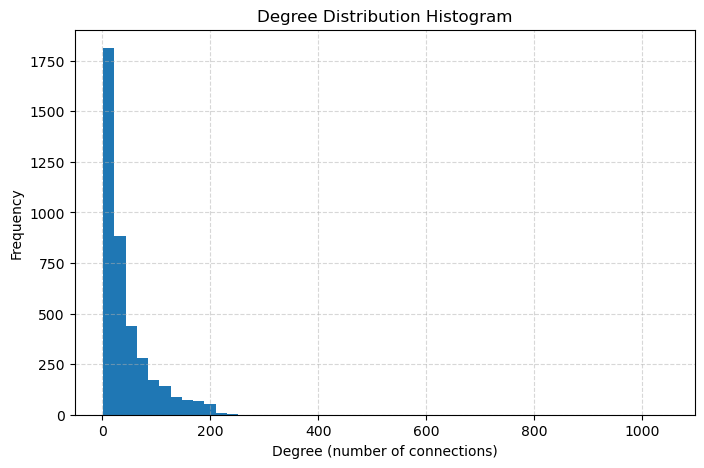

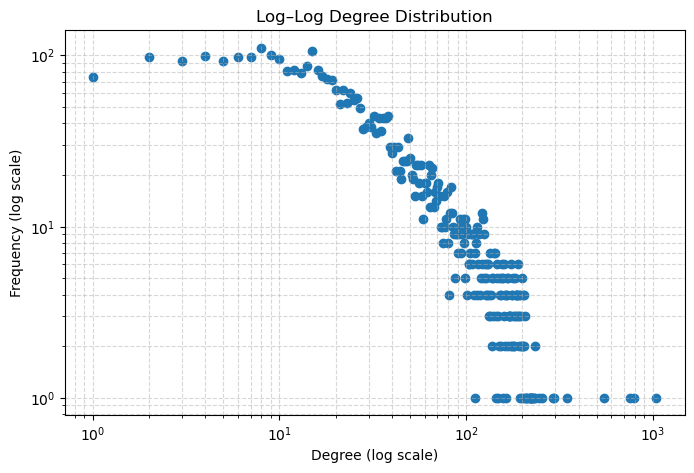

In [46]:
save = os.path.join(path, "Degree Distribution Histogram.png")
degree_sequence = [degree for node, degree in G.degree()]
# Degree Distribution Histogram
plt.figure(figsize=(8,5))
plt.hist(degree_sequence, bins=50)
plt.xlabel("Degree (number of connections)")
plt.ylabel("Frequency")
plt.title("Degree Distribution Histogram")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(save)
plt.show()

save = os.path.join(path, "Log–Log Degree Distribution.png")
#  Log–Log Scale Degree Distribution Scatter Plot
from collections import Counter

# Count frequency of each degree value
degree_count = Counter(degree_sequence)
deg, cnt = zip(*degree_count.items())

plt.figure(figsize=(8,5))
plt.scatter(deg, cnt)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Log–Log Degree Distribution")
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.savefig(save)
plt.show()

### 🔀 Edge Betweenness Centrality Analysis

This code computes **edge betweenness centrality**, a measure of how often an edge lies on shortest paths between nodes—indicating its importance in information flow.

A **histogram** visualises the distribution of centrality values, helping identify critical edges that act as key bridges within the network. 🌉


Computed Edge Betweenness Centrality for 88234 edges


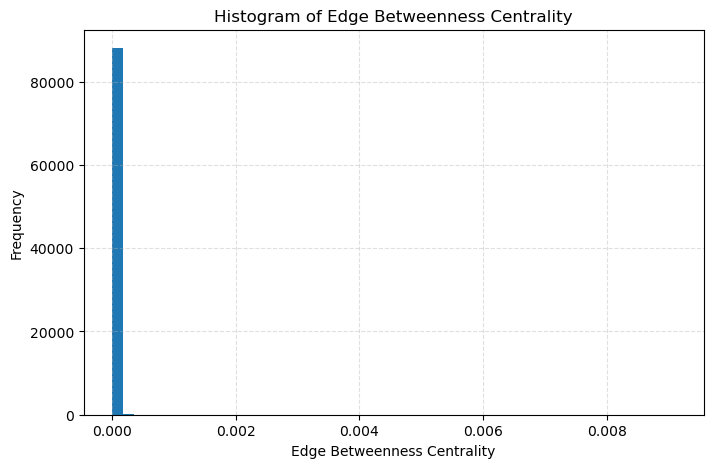

In [48]:
# Compute edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(G, k=200, seed=42)

# Convert to list of values
ec_values = list(edge_betweenness.values())

print("Computed Edge Betweenness Centrality for", len(ec_values), "edges")

save = os.path.join(path, "Edge Betweenness Centrality.png")
# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(ec_values, bins=50)
plt.xlabel("Edge Betweenness Centrality")
plt.ylabel("Frequency")
plt.title("Histogram of Edge Betweenness Centrality")
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(save)
plt.show()

### 🥇 Top Edges by Betweenness Centrality

This section ranks edges by **edge betweenness centrality**, listing the **top 10 most influential edges** responsible for major information flow across the network.

Identifying these high-centrality edges helps detect critical bridges whose removal could significantly disrupt network connectivity. 🔗


In [50]:

# Display top 10 edges
top_edges = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 edges by Edge Betweenness Centrality:")
for edge, score in top_edges:
    print(edge, score)

# Plot - Histogram
ec_values = list(edge_betweenness.values())


Top 10 edges by Edge Betweenness Centrality:
(107, 1684) 0.009107984762757836
(107, 1085) 0.00618219185231817
(1085, 3437) 0.004578494682596185
(0, 107) 0.004432216592864158
(567, 3437) 0.0039472105261372376
(58, 1684) 0.0037144343399147643
(58, 1912) 0.0036949358574382323
(3437, 698) 0.002796372117907223
(1684, 860) 0.0026675864497192623
(698, 860) 0.002659150321037254


### 🧠 Community Detection (Louvain & Label Propagation)

This code applies **Louvain community detection** to identify clusters of densely connected nodes and evaluates community structure using **modularity**. It also compares results with **Label Propagation**.

Key outputs:
- **Number and size** of detected communities (largest vs. smallest)
- **Modularity score** indicating community quality
- **Histogram of community sizes** to visualise distribution patterns

These results reveal structural grouping and segmentation within the network. 🧩


Louvain: Number of detected communities: 16
Largest community size: 548
Smallest community size: 19
Modularity Score (Louvain): 0.835

Label Propagation: Number of detected communities: 44
Largest LP community size: 1030
Smallest LP community size: 2


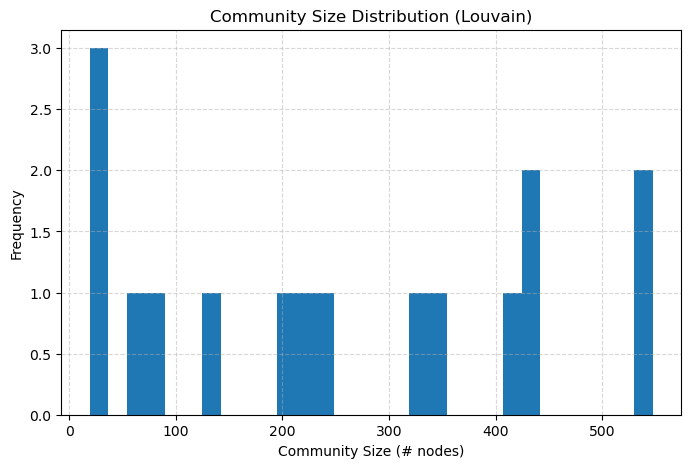

In [56]:
import community.community_louvain as community_louvain   # Louvain algorithm


# --------- Louvain Community Detection ---------
louvain_communities = community_louvain.best_partition(G)
num_communities_louvain = len(set(louvain_communities.values()))
print("Louvain: Number of detected communities:", num_communities_louvain)

# Convert dict to list of community groups
community_sizes_louvain = {}
for node, community_id in louvain_communities.items():
    community_sizes_louvain.setdefault(community_id, []).append(node)

sizes_louvain = [len(v) for v in community_sizes_louvain.values()]
print("Largest community size:", max(sizes_louvain))
print("Smallest community size:", min(sizes_louvain))

# Modularity score
modularity_score = community_louvain.modularity(louvain_communities, G)
print("Modularity Score (Louvain):", round(modularity_score,4))

# --------- Label Propagation (comparison algorithm) ---------
lp_communities = list(nx.algorithms.community.label_propagation_communities(G))
lp_sizes = [len(c) for c in lp_communities]
print("\nLabel Propagation: Number of detected communities:", len(lp_sizes))
print("Largest LP community size:", max(lp_sizes))
print("Smallest LP community size:", min(lp_sizes))

save = os.path.join(path, "Community Size Distribution.png")
# --------- Histogram of Community Sizes (Required Visualisation) ---------
plt.figure(figsize=(8,5))
plt.hist(sizes_louvain, bins=30)
plt.title("Community Size Distribution (Louvain)")
plt.xlabel("Community Size (# nodes)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(save)
plt.show()
